In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/diabetes_cleaned.csv")

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,Unknown,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Unknown,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,Unknown,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,Unknown,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


In [3]:
print(df.shape)

df.info()

df.describe().T

(101766, 45)
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   payer_code                101766 non-null  str  
 8   medical_specialty         101766 non-null  str  
 9   num_lab_procedures        101766 non-null  int64
 10  num_procedures            101766 non-null  int64
 11  num_medications           101766 non-null  int64
 12  number_outpatient         101766 non-null  int64
 13  number_emergency          101766 non-null  int64
 14  number_inpatient  

,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


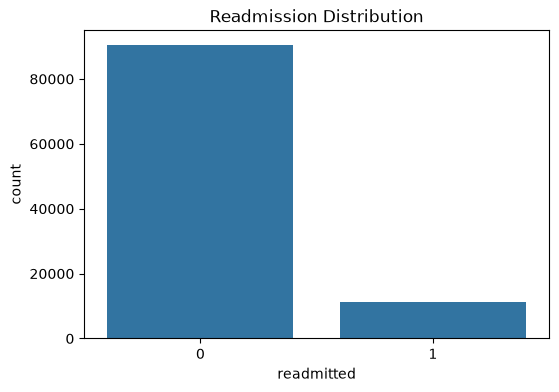

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="readmitted", data=df)

plt.title("Readmission Distribution")
plt.show()

In [5]:
(df["readmitted"].value_counts(normalize=True)*100).round(2)

readmitted
0    88.84
1    11.16
Name: proportion, dtype: float64

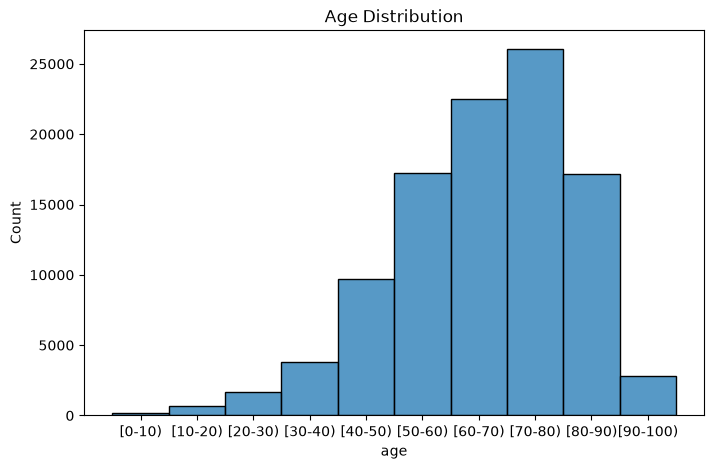

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=10)

plt.title("Age Distribution")

plt.show()

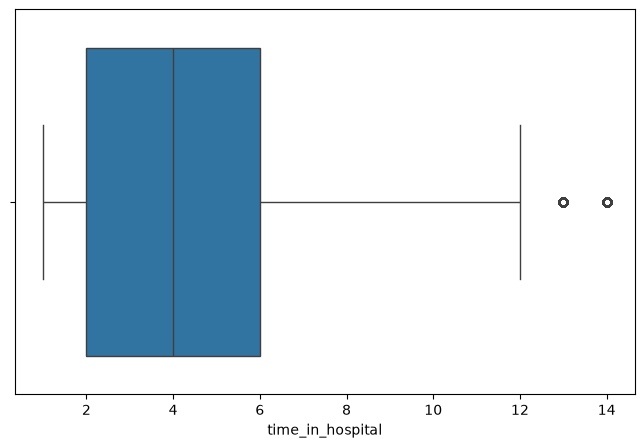

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["time_in_hospital"])

plt.show()

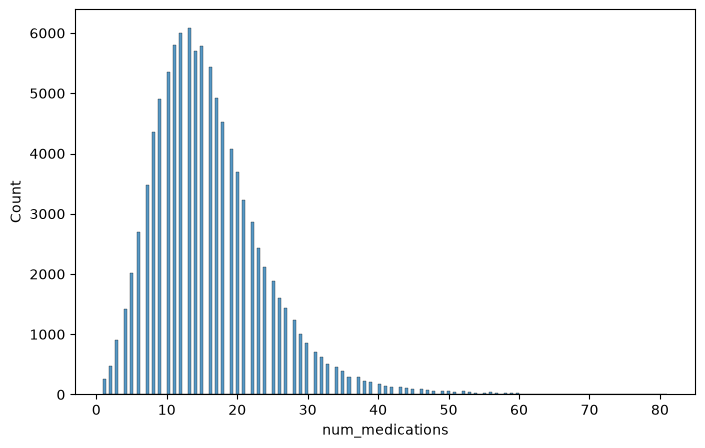

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["num_medications"])

plt.show()

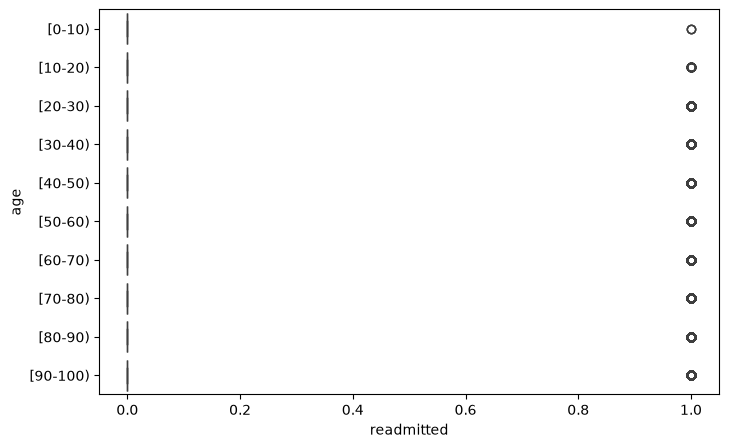

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="readmitted",
    y="age",
    data=df
)

plt.show()

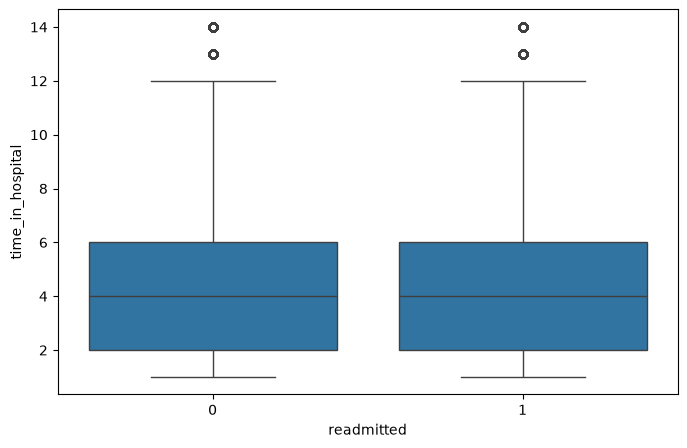

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="readmitted",
    y="time_in_hospital",
    data=df
)

plt.show()

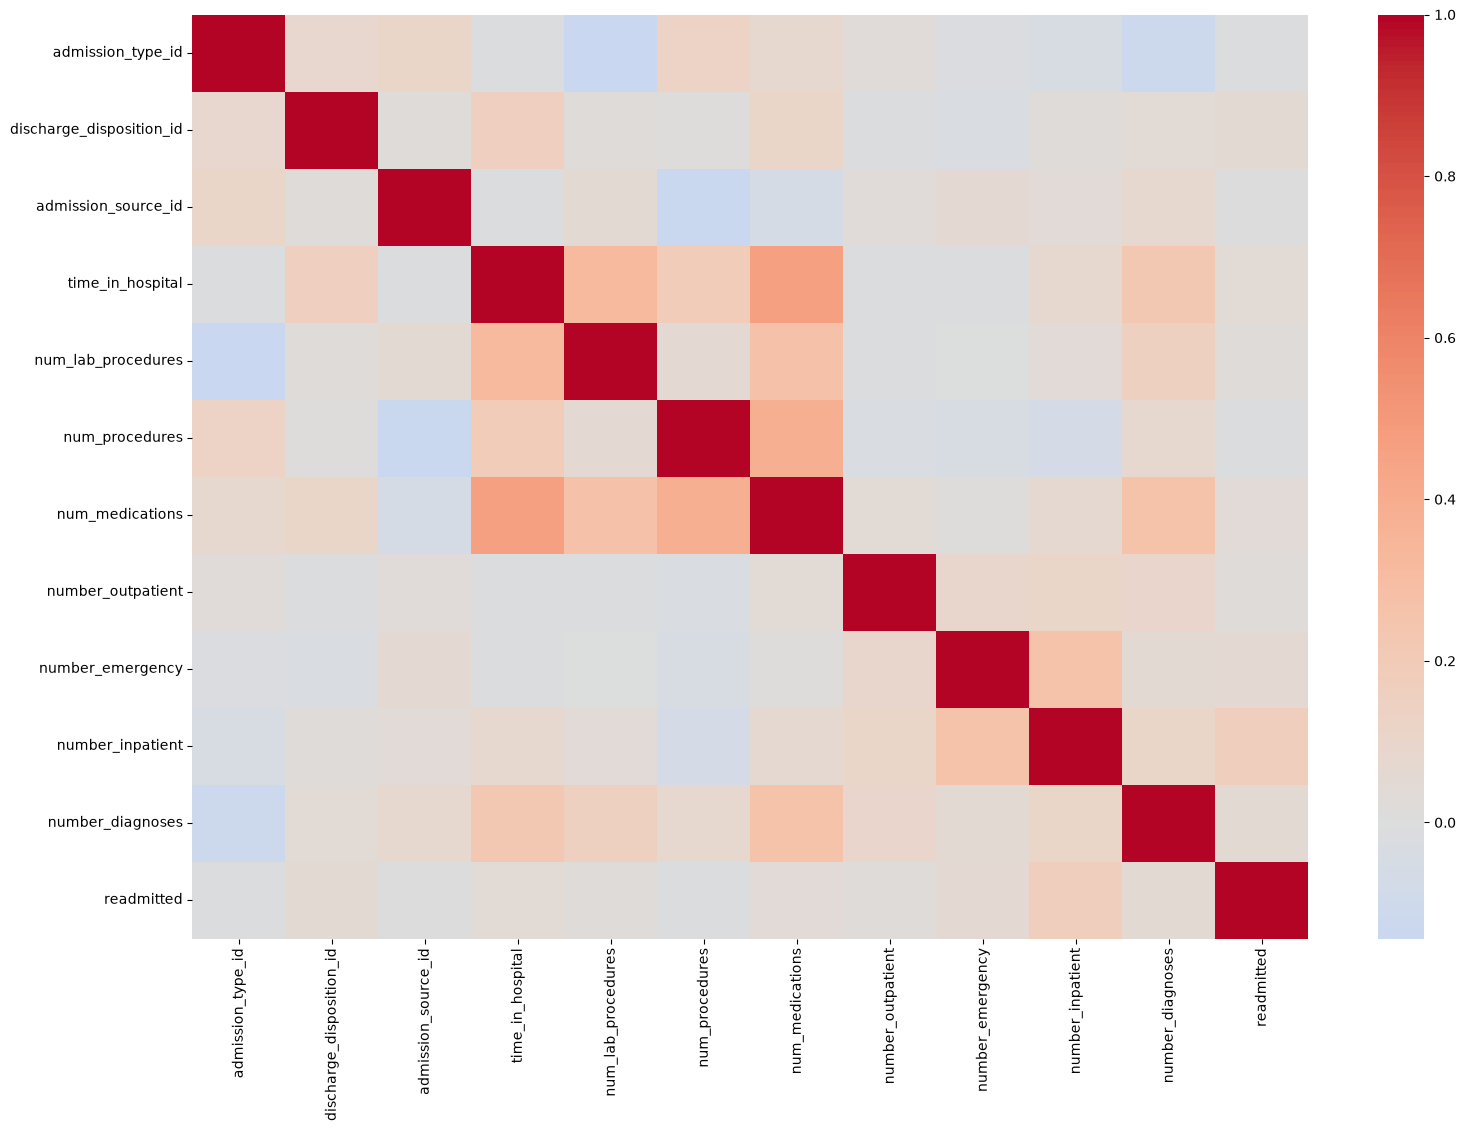

In [11]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

In [12]:
corr = numeric_df.corr()["readmitted"].sort_values(ascending=False)

print(corr.head(15))

readmitted                  1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
admission_source_id         0.005820
admission_type_id          -0.011651
num_procedures             -0.012227
Name: readmitted, dtype: float64


In [13]:
print(corr.tail(15))

readmitted                  1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
admission_source_id         0.005820
admission_type_id          -0.011651
num_procedures             -0.012227
Name: readmitted, dtype: float64


In [14]:
df.isnull().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
diag_3                       1423
diag_2                        358
diag_1                         21
admission_source_id             0
time_in_hospital                0
payer_code                      0
race                            0
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
number_outpatient               0
num_medications                 0
num_procedures                  0
num_lab_procedures              0
medical_specialty               0
number_inpatient                0
number_emergency                0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide   

## Key Findings

- Dataset contains 101766 rows.
- Readmission class distribution:
  - 0 → 88.84%
  - 1 → 11.16%
- Older patients appear to high
- Higher inpatient visits seem to low
- Longer hospital stays appear to low
- No remaining missing values.